In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

apps_df = pd.read_csv('googleplaystore.csv')
reviews_df = pd.read_csv('googleplaystore_user_reviews.csv')

apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
print("Apps shape:", apps_df.shape)
print(apps_df.isnull().sum())
print("\nReviews shape:", reviews_df.shape)
print(reviews_df.isnull().sum())

Apps shape: (10841, 13)
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Reviews shape: (64295, 5)
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


In [6]:
# Clean apps_df
apps_df['Rating'] = apps_df['Rating'].fillna(apps_df['Rating'].median())
apps_df = apps_df.dropna(subset=['Type', 'Content Rating', 'Current Ver', 'Android Ver'])

# Clean reviews_df - drop rows with no review text
reviews_df = reviews_df.dropna(subset=['Translated_Review'])

print("Apps shape after cleaning:", apps_df.shape)
print("Reviews shape after cleaning:", reviews_df.shape)

Apps shape after cleaning: (10829, 13)
Reviews shape after cleaning: (37427, 5)


In [7]:
# Clean Installs: remove '+' and ',' then convert to int
apps_df['Installs'] = apps_df['Installs'].str.replace('+', '', regex=False)
apps_df['Installs'] = apps_df['Installs'].str.replace(',', '', regex=False)
apps_df = apps_df[apps_df['Installs'] != 'Free']  # drop the one bad row if it exists
apps_df['Installs'] = apps_df['Installs'].astype(int)

# Clean Price: remove '$' then convert to float
apps_df['Price'] = apps_df['Price'].str.replace('$', '', regex=False).astype(float)

# Clean Size: convert M/k to numeric MB, keep 'Varies with device' as NaN
def clean_size(size):
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size:
        return float(size.replace('k', '')) / 1024
    else:
        return np.nan

apps_df['Size'] = apps_df['Size'].apply(clean_size)

print(apps_df[['Installs', 'Price', 'Size']].dtypes)
print(apps_df[['Installs', 'Price', 'Size']].describe())

Installs      int64
Price       float64
Size        float64
dtype: object
           Installs         Price         Size
count  1.082900e+04  10829.000000  9135.000000
mean   1.547990e+07      1.028091    21.534596
std    8.507114e+07     15.957778    22.593997
min    0.000000e+00      0.000000     0.008301
25%    5.000000e+03      0.000000     4.900000
50%    1.000000e+05      0.000000    13.000000
75%    5.000000e+06      0.000000    30.000000
max    1.000000e+09    400.000000   100.000000


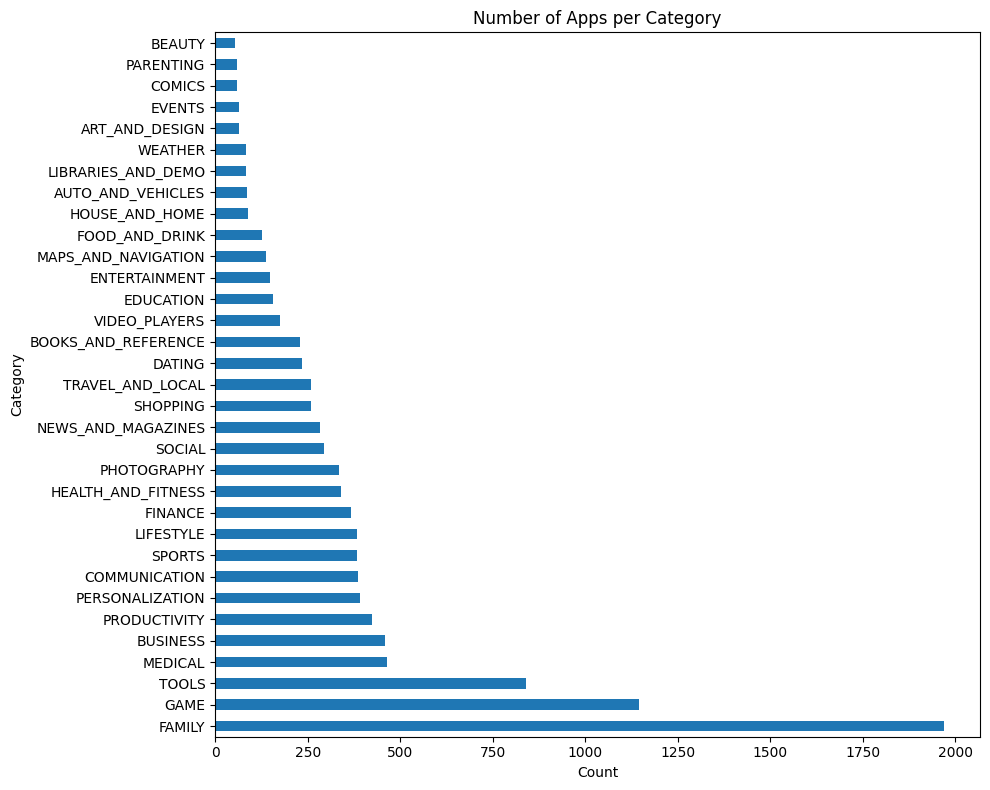

In [8]:
plt.figure(figsize=(10,8))
apps_df['Category'].value_counts().plot(kind='barh')
plt.title('Number of Apps per Category')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

Ob**servation**

FAMILY is the most saturated category with nearly 1,900 apps, followed by GAME (~1,150) and TOOLS (~850) — these three dominate the Play Store. In contrast, categories like Beauty, Parenting, Comics, and Events have very few apps, suggesting less competition but also potentially smaller demand.

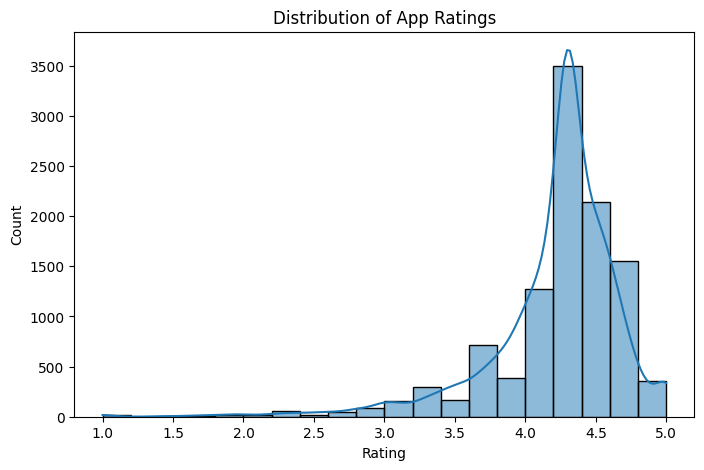

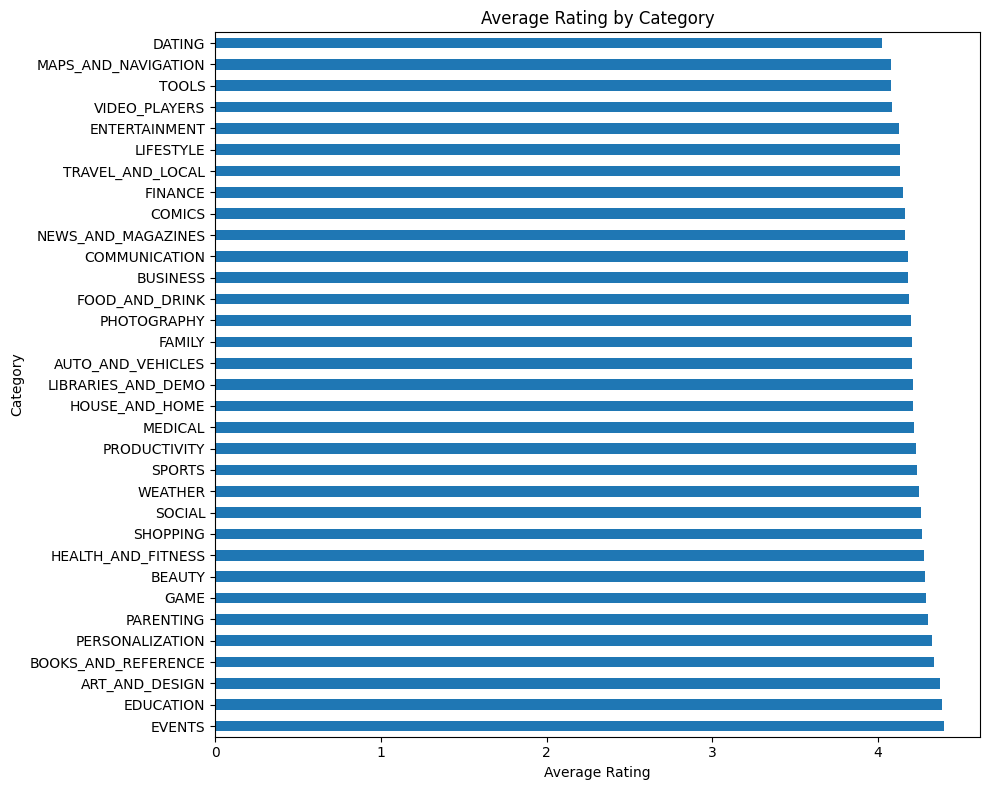

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(apps_df['Rating'], bins=20, kde=True)
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.show()

avg_rating_by_cat = apps_df.groupby('Category')['Rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,8))
avg_rating_by_cat.plot(kind='barh')
plt.title('Average Rating by Category')
plt.xlabel('Average Rating')
plt.tight_layout()
plt.show()

**Observation:**

App ratings are heavily right-skewed — most apps cluster between 4.0 and 4.5, with very few rated below 3.0. This is common on app stores since poorly-performing apps are often removed rather than staying listed. Average ratings vary little across categories (mostly within 4.0-4.4), with DATING and MAPS_AND_NAVIGATION ranking slightly higher and EVENTS slightly lower — suggesting category alone isn't a strong driver of app quality perception.

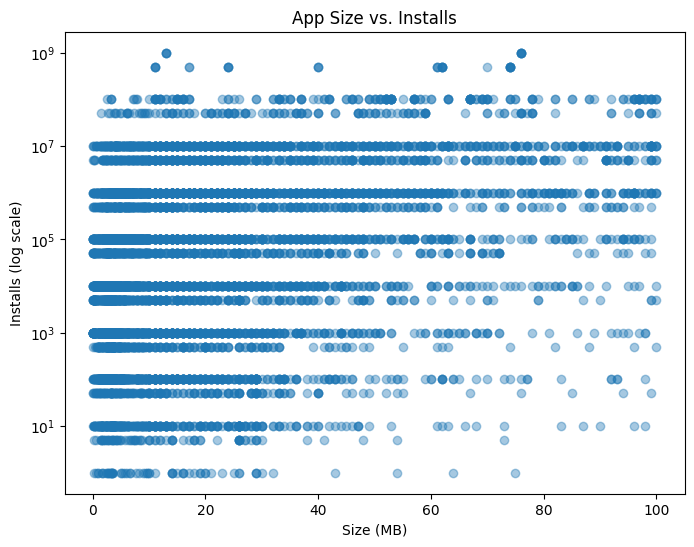

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(apps_df['Size'], apps_df['Installs'], alpha=0.4)
plt.yscale('log')
plt.xlabel('Size (MB)')
plt.ylabel('Installs (log scale)')
plt.title('App Size vs. Installs')
plt.show()

**Observation:**

There's no strong visible correlation between app size and number of installs both small and large apps span the full range of install counts. This suggests users don't necessarily favor lighter apps; other factors (category, marketing, app quality) likely matter more than file size for popularity.Observation: There's no strong visible correlation between app size and number of installs both small and large apps span the full range of install counts. This suggests users don't necessarily favor lighter apps; other factors (category, marketing, app quality) likely matter more than file size for popularity.

Type
Free    10032
Paid      797
Name: count, dtype: int64


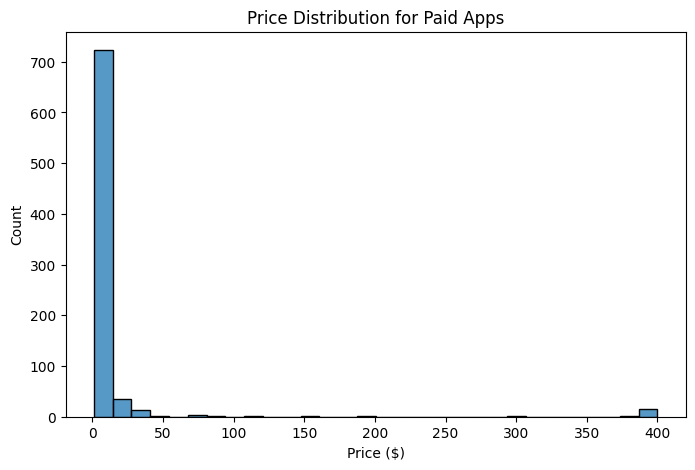

In [12]:
print(apps_df['Type'].value_counts())

paid_apps = apps_df[apps_df['Price'] > 0]
plt.figure(figsize=(8,5))
sns.histplot(paid_apps['Price'], bins=30)
plt.title('Price Distribution for Paid Apps')
plt.xlabel('Price ($)')
plt.show()

**Observation:**

The Play Store is overwhelmingly free — only about 7% of apps (797 of 10,829) are paid. Among paid apps, prices are heavily concentrated under $10, with a long tail of a few outliers priced above $300-400 (likely novelty or "joke" apps rather than genuine pricing). This confirms the freemium/ad-supported model dominates the Android app ecosystem.

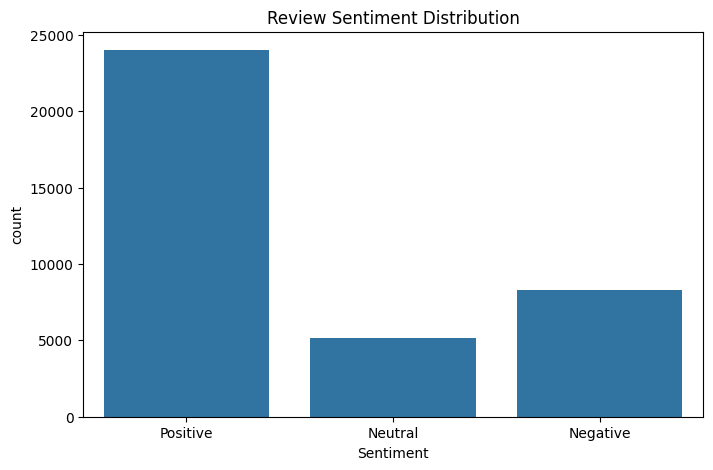

Category
COMICS                 0.468482
EVENTS                 0.377933
AUTO_AND_VEHICLES      0.348683
PARENTING              0.318880
WEATHER                0.282033
HEALTH_AND_FITNESS     0.278884
MAPS_AND_NAVIGATION    0.267218
FOOD_AND_DRINK         0.253251
PERSONALIZATION        0.252074
EDUCATION              0.251392
Name: Sentiment_Polarity, dtype: float64


In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='Sentiment', data=reviews_df, order=['Positive','Neutral','Negative'])
plt.title('Review Sentiment Distribution')
plt.show()

# Sentiment by category - merge with apps_df
merged = reviews_df.merge(apps_df[['App','Category']], on='App', how='left')
sentiment_by_cat = merged.groupby('Category')['Sentiment_Polarity'].mean().sort_values(ascending=False).head(10)
print(sentiment_by_cat)

**Observation: **

User reviews are predominantly positive (~24,000 positive vs. ~9,000 negative, ~6,000 neutral), suggesting most users leave feedback when satisfied. COMICS apps have the highest average sentiment polarity (0.47), followed by Events, Auto & Vehicles, and Parenting indicating strong user satisfaction in these niche categories despite their lower app counts.

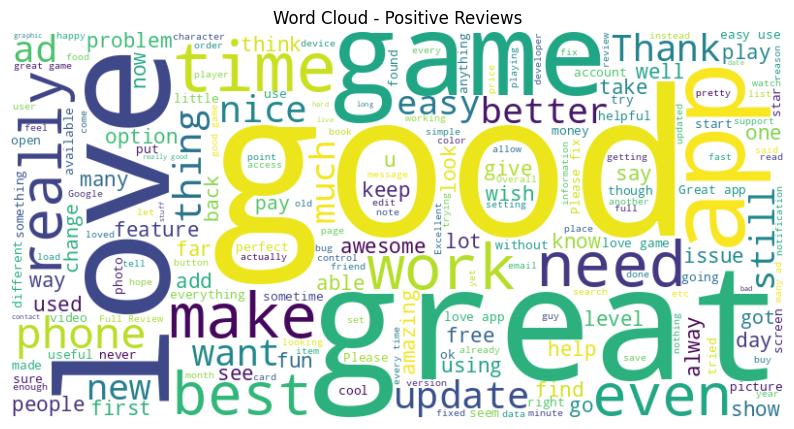

In [14]:
!pip install wordcloud
from wordcloud import WordCloud

positive_reviews = ' '.join(reviews_df[reviews_df['Sentiment']=='Positive']['Translated_Review'])
wc = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)

plt.figure(figsize=(10,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Reviews')
plt.show()

Conclusion: The Play Store is dominated by free apps (93%) concentrated in FAMILY, GAME, and TOOLS categories, with ratings skewing positive overall (mostly 4.0-4.5). App size showed no meaningful correlation with install counts, suggesting other factors drive downloads. User sentiment is largely positive, with niche categories like Comics and Events showing the strongest satisfaction. For a developer planning a new app: (1) less-saturated categories like Beauty or Parenting offer less competition, (2) a free/freemium model remains the dominant strategy, and (3) file size optimization is not a priority for driving installs focus on usability and marketing instead.